In [2]:
# Install required libraries
!pip install sympy nltk -q
import nltk
nltk.download('punkt', quiet=True)

import sympy as sp
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import random, math
from collections import Counter
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


Device: cuda


In [4]:
x = sp.Symbol('x')

def expr_to_prefix(expr):
    if expr.is_Integer:
        n = int(expr)
        return ['INT-', str(-n)] if n < 0 else ['INT+', str(n)]
    elif expr.is_Float:
        val = float(expr)
        return ['FLT-', f"{abs(val):.3f}"] if val < 0 else ['FLT+', f"{val:.3f}"]
    elif expr.is_Rational:
        sign = 'NEG' if expr.p < 0 else 'POS'
        return [sign, 'div', str(abs(expr.p)), str(abs(expr.q))]
    elif expr.is_Symbol:
        return [str(expr)]
    elif expr.is_Add:
        args = list(expr.args)
        result = expr_to_prefix(args[0])
        for arg in args[1:]:
            result = ['add'] + result + expr_to_prefix(arg)
        return result
    elif expr.is_Mul:
        args = list(expr.args)
        result = expr_to_prefix(args[0])
        for arg in args[1:]:
            result = ['mul'] + result + expr_to_prefix(arg)
        return result
    elif expr.is_Pow:
        return ['pow'] + expr_to_prefix(expr.args[0]) + expr_to_prefix(expr.args[1])
    elif isinstance(expr, sp.sin):   return ['sin']  + expr_to_prefix(expr.args[0])
    elif isinstance(expr, sp.cos):   return ['cos']  + expr_to_prefix(expr.args[0])
    elif isinstance(expr, sp.tan):   return ['tan']  + expr_to_prefix(expr.args[0])
    elif isinstance(expr, sp.exp):   return ['exp']  + expr_to_prefix(expr.args[0])
    elif isinstance(expr, sp.log):   return ['log']  + expr_to_prefix(expr.args[0])
    elif isinstance(expr, sp.sinh):  return ['sinh'] + expr_to_prefix(expr.args[0])
    elif isinstance(expr, sp.cosh):  return ['cosh'] + expr_to_prefix(expr.args[0])
    elif isinstance(expr, sp.tanh):  return ['tanh'] + expr_to_prefix(expr.args[0])
    elif isinstance(expr, sp.sqrt):  return ['sqrt'] + expr_to_prefix(expr.args[0])
    elif isinstance(expr, sp.Abs):   return ['abs']  + expr_to_prefix(expr.args[0])
    else:
        return ['UNK']

def generate_dataset(n_samples=5000, order=4):
    unary_fns = [sp.sin, sp.cos, sp.exp, sp.sinh, sp.cosh, sp.tan, sp.tanh]

    def random_function():
        kind = random.randint(0, 5)
        c = random.choice([-2, -1, 1, 2])
        if kind == 0:
            deg = random.randint(1, 4)
            coeffs = [random.randint(-3, 3) for _ in range(deg + 1)]
            return sum(ci * x**i for i, ci in enumerate(coeffs) if ci != 0) or x
        elif kind == 1:
            return random.choice(unary_fns)(c * x)
        elif kind == 2:
            return random.choice(unary_fns[:4])(x) + c * x**random.randint(1, 3)
        elif kind == 3:
            return x * random.choice([sp.sin, sp.cos, sp.exp])(c * x)
        elif kind == 4:
            f1, f2 = random.sample(unary_fns[:4], 2)
            return f1(x) + c * f2(x)
        else:
            f1, f2 = random.sample([sp.sin, sp.cos], 2)
            return f1(x) * f2(c * x)

    pairs = []
    attempts = 0
    while len(pairs) < n_samples and attempts < n_samples * 5:
        attempts += 1
        try:
            f = random_function()
            taylor = sp.series(f, x, 0, order + 1).removeO()
            taylor = sp.expand(taylor)
            if taylor == 0 or taylor is sp.nan:
                continue
            src = expr_to_prefix(f)
            tgt = expr_to_prefix(taylor)
            if 1 <= len(src) <= 40 and 1 <= len(tgt) <= 50:
                pairs.append((src, tgt))
        except:
            continue

    print(f"✅ Generated {len(pairs)} valid pairs from {attempts} attempts")
    print("\n📊 Sample (Function → Taylor Expansion):")
    for src, tgt in random.sample(pairs, 5):
        print(f"  Function : {' '.join(src)}")
        print(f"  Taylor   : {' '.join(tgt)}")
        print()
    return pairs

pairs = generate_dataset(5000, order=4)


✅ Generated 5000 valid pairs from 5000 attempts

📊 Sample (Function → Taylor Expansion):
  Function : add sin x sinh x
  Taylor   : mul INT+ 2 x

  Function : add INT+ 1 mul INT- 3 x
  Taylor   : add INT+ 1 mul INT- 3 x

  Function : add add INT- 2 mul INT- 1 pow x INT+ 2 mul INT+ 3 x
  Taylor   : add add INT- 2 mul INT- 1 pow x INT+ 2 mul INT+ 3 x

  Function : mul cos x sin x
  Taylor   : add x mul NEG div 2 3 pow x INT+ 3

  Function : mul mul INT- 1 cos x sin mul INT+ 2 x
  Taylor   : add mul INT- 2 x mul POS div 7 3 pow x INT+ 3



In [5]:
PAD, SOS, EOS, UNK = '<PAD>', '<SOS>', '<EOS>', '<UNK>'

class Vocabulary:
    def __init__(self):
        self.w2i = {PAD: 0, SOS: 1, EOS: 2, UNK: 3}
        self.i2w = {0: PAD, 1: SOS, 2: EOS, 3: UNK}

    def build(self, all_tokens):
        for tok in set(all_tokens):
            if tok not in self.w2i:
                i = len(self.w2i)
                self.w2i[tok] = i
                self.i2w[i] = tok
        print(f"Vocabulary size: {len(self.w2i)}")

    def encode(self, tokens):
        return [self.w2i.get(t, self.w2i[UNK]) for t in tokens]

    def decode(self, ids):
        return [self.i2w.get(i, UNK) for i in ids]

    def __len__(self):
        return len(self.w2i)

vocab = Vocabulary()
vocab.build([t for src, tgt in pairs for t in src + tgt])

# Encode all pairs with SOS/EOS
def encode_pair(src_toks, tgt_toks):
    src = [vocab.w2i[SOS]] + vocab.encode(src_toks) + [vocab.w2i[EOS]]
    tgt = [vocab.w2i[SOS]] + vocab.encode(tgt_toks) + [vocab.w2i[EOS]]
    return src, tgt

encoded = [encode_pair(s, t) for s, t in pairs]

# Split 80/10/10
random.shuffle(encoded)
n = len(encoded)
train_data = encoded[:int(0.8*n)]
val_data   = encoded[int(0.8*n):int(0.9*n)]
test_data  = encoded[int(0.9*n):]
print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")


Vocabulary size: 32
Train: 4000 | Val: 500 | Test: 500


In [6]:
class TaylorDataset(Dataset):
    def __init__(self, data): self.data = data
    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return self.data[idx]

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src = nn.utils.rnn.pad_sequence([torch.tensor(s) for s in src_batch], batch_first=True, padding_value=0)
    tgt = nn.utils.rnn.pad_sequence([torch.tensor(t) for t in tgt_batch], batch_first=True, padding_value=0)
    return src, tgt

BATCH_SIZE = 64
train_loader = DataLoader(TaylorDataset(train_data), batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(TaylorDataset(val_data),   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(TaylorDataset(test_data),  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)


In [13]:
class LSTMEncoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hid_dim, n_layers, batch_first=True,
                            dropout=dropout if n_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
    def forward(self, src):
      output, (hidden, cell) = self.lstm(self.dropout(self.embedding(src)))
      return output, hidden, cell


class LSTMDecoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hid_dim, n_layers, batch_first=True,
                            dropout=dropout if n_layers > 1 else 0)
        self.fc = nn.Linear(hid_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)
    def forward(self, token, hidden, cell):
        emb = self.dropout(self.embedding(token.unsqueeze(1)))
        out, (hidden, cell) = self.lstm(emb, (hidden, cell))
        return self.fc(out.squeeze(1)), hidden, cell

class LSTMSeq2Seq(nn.Module):
    def __init__(self, enc, dec):
        super().__init__()
        self.encoder = enc
        self.decoder = dec
    def forward(self, src, tgt, tf_ratio=0.5):
        B, T = tgt.shape
        vocab_size = self.decoder.fc.out_features
        outputs = torch.zeros(B, T, vocab_size).to(src.device)
        _, hidden, cell = self.encoder(src)
        dec_in = tgt[:, 0]
        for t in range(1, T):
            out, hidden, cell = self.decoder(dec_in, hidden, cell)
            outputs[:, t] = out
            dec_in = tgt[:, t] if random.random() < tf_ratio else out.argmax(1)
        return outputs


In [14]:
class PositionalEncoding(nn.Module):
    def __init__(self, emb_dim, max_len=300, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, emb_dim)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, emb_dim, 2).float() * (-math.log(10000.0) / emb_dim))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class TransformerSeq2Seq(nn.Module):
    def __init__(self, vocab_size, emb_dim, nhead, n_enc, n_dec, ff_dim, dropout):
        super().__init__()
        self.src_emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.tgt_emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.pos_enc = PositionalEncoding(emb_dim, dropout=dropout)
        self.transformer = nn.Transformer(
            d_model=emb_dim, nhead=nhead,
            num_encoder_layers=n_enc, num_decoder_layers=n_dec,
            dim_feedforward=ff_dim, dropout=dropout, batch_first=True
        )
        self.fc = nn.Linear(emb_dim, vocab_size)
        self.scale = math.sqrt(emb_dim)

    def forward(self, src, tgt):
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt.size(1)).to(src.device)
        src_pad  = (src == 0)
        tgt_pad  = (tgt == 0)
        src_emb = self.pos_enc(self.src_emb(src) * self.scale)
        tgt_emb = self.pos_enc(self.tgt_emb(tgt) * self.scale)
        out = self.transformer(src_emb, tgt_emb,
                               tgt_mask=tgt_mask,
                               src_key_padding_mask=src_pad,
                               tgt_key_padding_mask=tgt_pad,
                               memory_key_padding_mask=src_pad)
        return self.fc(out)


In [15]:
criterion = nn.CrossEntropyLoss(ignore_index=0)

def run_epoch(model, loader, optimizer=None, model_type='lstm'):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0
    with torch.set_grad_enabled(is_train):
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)
            if model_type == 'lstm':
                out = model(src, tgt, tf_ratio=0.5 if is_train else 0.0)
                out = out[:, 1:].reshape(-1, out.size(-1))
                lbl = tgt[:, 1:].reshape(-1)
            else:
                out = model(src, tgt[:, :-1])
                out = out.reshape(-1, out.size(-1))
                lbl = tgt[:, 1:].reshape(-1)
            loss = criterion(out, lbl)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item()
    return total_loss / len(loader)

def token_accuracy(model, loader, model_type):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)
            if model_type == 'lstm':
                out = model(src, tgt, tf_ratio=0.0)
                preds, labels = out[:, 1:].argmax(-1), tgt[:, 1:]
            else:
                out = model(src, tgt[:, :-1])
                preds, labels = out.argmax(-1), tgt[:, 1:]
            mask = labels != 0
            correct += (preds == labels)[mask].sum().item()
            total   += mask.sum().item()
    return correct / total

def sequence_accuracy(model, data, vocab, model_type, n=300):
    model.eval()
    SOS_I, EOS_I = vocab.w2i[SOS], vocab.w2i[EOS]
    correct = 0
    samples = random.sample(data, min(n, len(data)))
    with torch.no_grad():
        for src_enc, tgt_enc in samples:
            src = torch.tensor([src_enc]).to(device)
            if model_type == 'lstm':
                _, hidden, cell = model.encoder(src)
                dec_in = torch.tensor([SOS_I]).to(device)
                pred = []
                for _ in range(60):
                    out, hidden, cell = model.decoder(dec_in, hidden, cell)
                    tok = out.argmax(1).item()
                    if tok == EOS_I: break
                    pred.append(tok)
                    dec_in = torch.tensor([tok]).to(device)
            else:
                tgt_inp = torch.tensor([[SOS_I]]).to(device)
                pred = []
                for _ in range(60):
                    out = model(src, tgt_inp)
                    tok = out[:, -1, :].argmax(-1).item()
                    if tok == EOS_I: break
                    pred.append(tok)
                    tgt_inp = torch.cat([tgt_inp, torch.tensor([[tok]]).to(device)], dim=1)
            truth = [t for t in tgt_enc if t not in [SOS_I, EOS_I, 0]]
            if pred == truth:
                correct += 1
    return correct / len(samples)

def compute_bleu(model, data, vocab, model_type, n=300):
    model.eval()
    SOS_I, EOS_I = vocab.w2i[SOS], vocab.w2i[EOS]
    refs, hyps = [], []
    samples = random.sample(data, min(n, len(data)))
    sf = SmoothingFunction().method1
    with torch.no_grad():
        for src_enc, tgt_enc in samples:
            src = torch.tensor([src_enc]).to(device)
            truth = [vocab.i2w.get(t, UNK) for t in tgt_enc if t not in [SOS_I, EOS_I, 0]]
            if model_type == 'lstm':
                _, hidden, cell = model.encoder(src)
                dec_in = torch.tensor([SOS_I]).to(device)
                pred = []
                for _ in range(60):
                    out, hidden, cell = model.decoder(dec_in, hidden, cell)
                    tok = out.argmax(1).item()
                    if tok == EOS_I: break
                    pred.append(vocab.i2w.get(tok, UNK))
                    dec_in = torch.tensor([tok]).to(device)
            else:
                tgt_inp = torch.tensor([[SOS_I]]).to(device)
                pred = []
                for _ in range(60):
                    out = model(src, tgt_inp)
                    tok = out[:, -1, :].argmax(-1).item()
                    if tok == EOS_I: break
                    pred.append(vocab.i2w.get(tok, UNK))
                    tgt_inp = torch.cat([tgt_inp, torch.tensor([[tok]]).to(device)], dim=1)
            refs.append([truth])
            hyps.append(pred if pred else [UNK])
    return corpus_bleu(refs, hyps, smoothing_function=sf)


In [16]:
VOCAB_SIZE = len(vocab)
N_EPOCHS   = 35

lstm_enc   = LSTMEncoder(VOCAB_SIZE, emb_dim=128, hid_dim=256, n_layers=2, dropout=0.3)
lstm_dec   = LSTMDecoder(VOCAB_SIZE, emb_dim=128, hid_dim=256, n_layers=2, dropout=0.3)
lstm_model = LSTMSeq2Seq(lstm_enc, lstm_dec).to(device)
lstm_opt   = optim.Adam(lstm_model.parameters(), lr=1e-3)
lstm_sched = optim.lr_scheduler.ReduceLROnPlateau(lstm_opt, patience=4, factor=0.5)

lstm_train_losses, lstm_val_losses = [], []
best_lstm_loss = float('inf')

print("🔷 Training LSTM...")
for epoch in range(1, N_EPOCHS + 1):
    tr  = run_epoch(lstm_model, train_loader, lstm_opt,  'lstm')
    val = run_epoch(lstm_model, val_loader,   None,      'lstm')
    lstm_train_losses.append(tr)
    lstm_val_losses.append(val)
    lstm_sched.step(val)
    if val < best_lstm_loss:
        best_lstm_loss = val
        torch.save(lstm_model.state_dict(), 'lstm_best.pt')
    if epoch % 5 == 0:
        print(f"Epoch {epoch:02d}/{N_EPOCHS} | Train: {tr:.4f} | Val: {val:.4f}")

lstm_model.load_state_dict(torch.load('lstm_best.pt'))
lstm_tok_acc = token_accuracy(lstm_model, test_loader, 'lstm')
lstm_seq_acc = sequence_accuracy(lstm_model, test_data, vocab, 'lstm')
lstm_bleu    = compute_bleu(lstm_model, test_data, vocab, 'lstm')
print(f"\n✅ LSTM → Token Acc: {lstm_tok_acc*100:.2f}% | Seq Acc: {lstm_seq_acc*100:.2f}% | BLEU: {lstm_bleu:.4f}")


🔷 Training LSTM...
Epoch 05/35 | Train: 0.6246 | Val: 2.9246
Epoch 10/35 | Train: 0.2678 | Val: 1.0106
Epoch 15/35 | Train: 0.0740 | Val: 0.1909
Epoch 20/35 | Train: 0.0294 | Val: 0.2670
Epoch 25/35 | Train: 0.0162 | Val: 0.0584
Epoch 30/35 | Train: 0.0085 | Val: 0.0282
Epoch 35/35 | Train: 0.0061 | Val: 0.0317

✅ LSTM → Token Acc: 99.50% | Seq Acc: 26.67% | BLEU: 0.5901


In [17]:
trans_model = TransformerSeq2Seq(
    vocab_size=VOCAB_SIZE, emb_dim=128, nhead=4,
    n_enc=3, n_dec=3, ff_dim=512, dropout=0.1
).to(device)
trans_opt   = optim.Adam(trans_model.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)
trans_sched = optim.lr_scheduler.ReduceLROnPlateau(trans_opt, patience=4, factor=0.5)


trans_train_losses, trans_val_losses = [], []
best_trans_loss = float('inf')

print("🔶 Training Transformer...")
for epoch in range(1, N_EPOCHS + 1):
    tr  = run_epoch(trans_model, train_loader, trans_opt, 'transformer')
    val = run_epoch(trans_model, val_loader,   None,      'transformer')
    trans_train_losses.append(tr)
    trans_val_losses.append(val)
    trans_sched.step(val)
    if val < best_trans_loss:
        best_trans_loss = val
        torch.save(trans_model.state_dict(), 'transformer_best.pt')
    if epoch % 5 == 0:
        print(f"Epoch {epoch:02d}/{N_EPOCHS} | Train: {tr:.4f} | Val: {val:.4f}")

trans_model.load_state_dict(torch.load('transformer_best.pt'))
trans_tok_acc = token_accuracy(trans_model, test_loader, 'transformer')
trans_seq_acc = sequence_accuracy(trans_model, test_data, vocab, 'transformer')
trans_bleu    = compute_bleu(trans_model, test_data, vocab, 'transformer')
print(f"\n✅ Transformer → Token Acc: {trans_tok_acc*100:.2f}% | Seq Acc: {trans_seq_acc*100:.2f}% | BLEU: {trans_bleu:.4f}")


🔶 Training Transformer...
Epoch 05/35 | Train: 0.4432 | Val: 0.3019
Epoch 10/35 | Train: 0.2617 | Val: 0.1612
Epoch 15/35 | Train: 0.1908 | Val: 0.1171
Epoch 20/35 | Train: 0.1535 | Val: 0.0907
Epoch 25/35 | Train: 0.1253 | Val: 0.0716
Epoch 30/35 | Train: 0.1097 | Val: 0.0615
Epoch 35/35 | Train: 0.0959 | Val: 0.0563

✅ Transformer → Token Acc: 97.94% | Seq Acc: 76.67% | BLEU: 0.8980


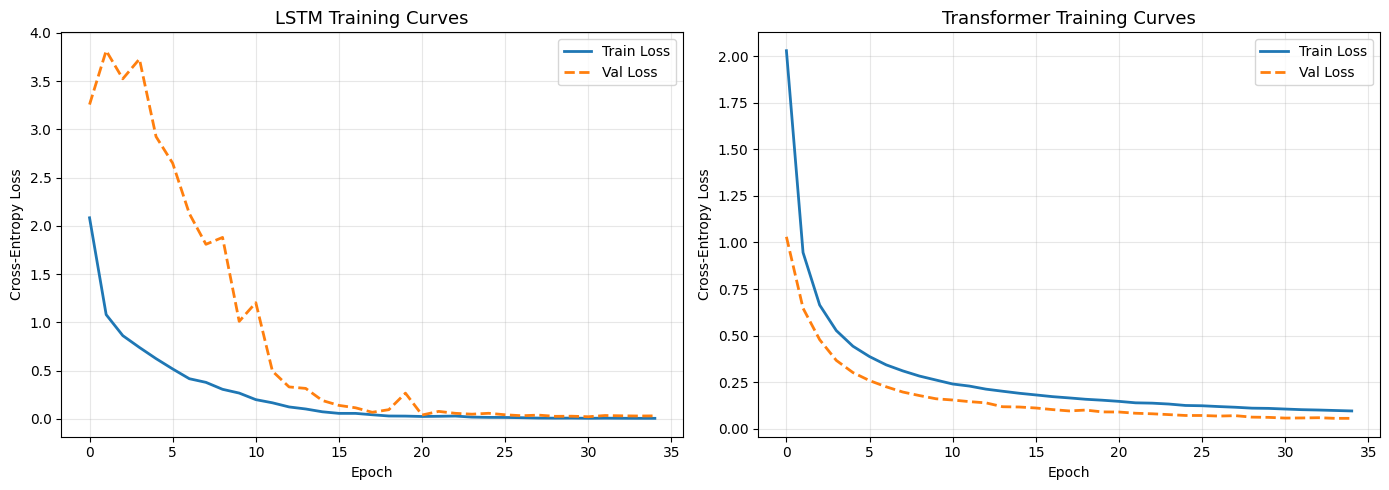


          📊 EVALUATION METRICS COMPARISON
Metric                               LSTM    Transformer
------------------------------------------------------------
Token Accuracy                     99.50%         97.94%
Sequence Accuracy                  26.67%         76.67%
BLEU Score                         0.5901         0.8980
Best Val Loss                      0.0227         0.0562
Perplexity                           1.02           1.06

📋 Sample Predictions (Transformer vs Ground Truth):

  Function : exp mul INT- 2 x
  Expected : add add add add INT+ 1 mul INT- 2 x mul INT+ 2 pow x INT+ 2 mul NEG div 4 3 pow x INT+ 3 mul POS div 2 3 pow x INT+ 4
  Predicted: add add add add INT+ 1 mul INT- 2 x mul INT+ 2 pow x INT+ 2 mul NEG div 4 3 pow x INT+ 3 mul POS div 4 3 pow x INT+ 4  ❌ WRONG

  Function : exp mul INT- 2 x
  Expected : add add add add INT+ 1 mul INT- 2 x mul INT+ 2 pow x INT+ 2 mul NEG div 4 3 pow x INT+ 3 mul POS div 2 3 pow x INT+ 4
  Predicted: add add add add INT+ 1 m

In [18]:
# --- Training Curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, tr, val, title in [
    (axes[0], lstm_train_losses,  lstm_val_losses,  "LSTM"),
    (axes[1], trans_train_losses, trans_val_losses, "Transformer")
]:
    ax.plot(tr,  label='Train Loss', linewidth=2)
    ax.plot(val, label='Val Loss',   linewidth=2, linestyle='--')
    ax.set_title(f'{title} Training Curves', fontsize=13)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-Entropy Loss')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Metrics Table ---
print("\n" + "="*60)
print("          📊 EVALUATION METRICS COMPARISON")
print("="*60)
print(f"{'Metric':<28} {'LSTM':>12} {'Transformer':>14}")
print("-"*60)
print(f"{'Token Accuracy':<28} {lstm_tok_acc*100:>11.2f}% {trans_tok_acc*100:>13.2f}%")
print(f"{'Sequence Accuracy':<28} {lstm_seq_acc*100:>11.2f}% {trans_seq_acc*100:>13.2f}%")
print(f"{'BLEU Score':<28} {lstm_bleu:>12.4f} {trans_bleu:>14.4f}")
print(f"{'Best Val Loss':<28} {best_lstm_loss:>12.4f} {best_trans_loss:>14.4f}")
print(f"{'Perplexity':<28} {math.exp(best_lstm_loss):>12.2f} {math.exp(best_trans_loss):>14.2f}")
print("="*60)

# --- Sample Predictions ---
print("\n📋 Sample Predictions (Transformer vs Ground Truth):\n")
SOS_I, EOS_I = vocab.w2i[SOS], vocab.w2i[EOS]
for src_enc, tgt_enc in random.sample(test_data, 6):
    src = torch.tensor([src_enc]).to(device)
    tgt_inp = torch.tensor([[SOS_I]]).to(device)
    pred = []
    with torch.no_grad():
        for _ in range(60):
            out = trans_model(src, tgt_inp)
            tok = out[:, -1, :].argmax(-1).item()
            if tok == EOS_I: break
            pred.append(tok)
            tgt_inp = torch.cat([tgt_inp, torch.tensor([[tok]]).to(device)], dim=1)

    fn_toks = vocab.decode([t for t in src_enc if t not in [SOS_I, EOS_I, 0]])
    gt_toks = vocab.decode([t for t in tgt_enc if t not in [SOS_I, EOS_I, 0]])
    pd_toks = vocab.decode(pred)
    match = "✅ CORRECT" if pd_toks == gt_toks else "❌ WRONG"
    print(f"  Function : {' '.join(fn_toks)}")
    print(f"  Expected : {' '.join(gt_toks)}")
    print(f"  Predicted: {' '.join(pd_toks)}  {match}")
    print()


In [19]:
# Save all results permanently
import json

results = {
    "lstm": {
        "token_accuracy": lstm_tok_acc,
        "sequence_accuracy": lstm_seq_acc,
        "bleu": lstm_bleu,
        "best_val_loss": best_lstm_loss,
        "perplexity": math.exp(best_lstm_loss)
    },
    "transformer": {
        "token_accuracy": trans_tok_acc,
        "sequence_accuracy": trans_seq_acc,
        "bleu": trans_bleu,
        "best_val_loss": best_trans_loss,
        "perplexity": math.exp(best_trans_loss)
    }
}

with open('results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("✅ Results saved!")

# Also download your notebook
from google.colab import files
files.download('training_curves.png')


✅ Results saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>